In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Install the Kaggle API client
!pip install kaggle

In [3]:
# Set up Kaggle authentication using Colab secrets
import os
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Define the dataset path and download it
dataset_path = 'ruchi798/data-science-job-salaries'
!kaggle datasets download -d {dataset_path}

# Unzip the downloaded file
!unzip data-science-job-salaries.zip

# Load the CSV file into a pandas DataFrame
import pandas as pd


Dataset URL: https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries
License(s): CC0-1.0
100% 7.37k/7.37k [00:00<00:00, 11.2MB/s]

Archive:  data-science-job-salaries.zip
  inflating: ds_salaries.csv         


In [4]:
df = pd.read_csv('ds_salaries.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [5]:
df.shape

(607, 12)

In [6]:
import pandas as pd

# Create a copy for cleaning
df_clean = df.copy()

# 1. Check for missing values
print("Missing values per column:")
print(df_clean.isnull().sum())

# 2. Check for and remove duplicate rows
duplicate_count = df_clean.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates()
    print("Duplicates removed.")

# 3. Clean string columns (strip whitespace)
string_cols = df_clean.select_dtypes(include=['object']).columns
for col in string_cols:
    df_clean[col] = df_clean[col].str.strip()

print(f"\nCleaned string columns: {list(string_cols)}")

# 4. Remove 'Unnamed: 0' if it's just an index artifact
if 'Unnamed: 0' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Unnamed: 0'])
    print("Removed 'Unnamed: 0' column.")

# Display summary of cleaned data
print("\nDataframe shape after cleaning:", df_clean.shape)
display(df_clean.head())

Missing values per column:
Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Number of duplicate rows: 0

Cleaned string columns: ['experience_level', 'employment_type', 'job_title', 'salary_currency', 'employee_residence', 'company_location', 'company_size']
Removed 'Unnamed: 0' column.

Dataframe shape after cleaning: (607, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


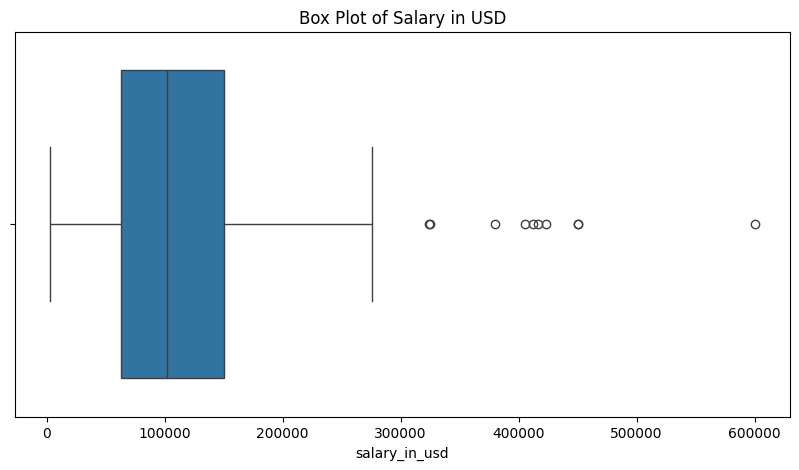

Q1: $62,726.00
Q3: $150,000.00
IQR: $87,274.00
Lower Bound: $-68,185.00
Upper Bound: $280,911.00

Number of outliers detected: 10

Top 5 Outlier Records:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
252,2021,EX,FT,Principal Data Engineer,600000,USD,600000,US,100,US,L
33,2020,MI,FT,Research Scientist,450000,USD,450000,US,0,US,M
97,2021,MI,FT,Financial Data Analyst,450000,USD,450000,US,100,US,L
157,2021,MI,FT,Applied Machine Learning Scientist,423000,USD,423000,US,50,US,L
225,2021,EX,CT,Principal Data Scientist,416000,USD,416000,US,100,US,S


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visual Inspection using Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_clean['salary_in_usd'])
plt.title('Box Plot of Salary in USD')
plt.show()

# 2. Statistical Identification using IQR
Q1 = df_clean['salary_in_usd'].quantile(0.25)
Q3 = df_clean['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['salary_in_usd'] < lower_bound) | (df_clean['salary_in_usd'] > upper_bound)]

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Lower Bound: ${lower_bound:,.2f}")
print(f"Upper Bound: ${upper_bound:,.2f}")
print(f"\nNumber of outliers detected: {len(outliers)}")

if len(outliers) > 0:
    print("\nTop 5 Outlier Records:")
    display(outliers.sort_values(by='salary_in_usd', ascending=False).head())

In [8]:
unique_titles = df_clean['job_title'].unique()
print(f'There are {len(unique_titles)} unique job titles.')
print(sorted(unique_titles))

There are 50 unique job titles.
['3D Computer Vision Researcher', 'AI Scientist', 'Analytics Engineer', 'Applied Data Scientist', 'Applied Machine Learning Scientist', 'BI Data Analyst', 'Big Data Architect', 'Big Data Engineer', 'Business Data Analyst', 'Cloud Data Engineer', 'Computer Vision Engineer', 'Computer Vision Software Engineer', 'Data Analyst', 'Data Analytics Engineer', 'Data Analytics Lead', 'Data Analytics Manager', 'Data Architect', 'Data Engineer', 'Data Engineering Manager', 'Data Science Consultant', 'Data Science Engineer', 'Data Science Manager', 'Data Scientist', 'Data Specialist', 'Director of Data Engineering', 'Director of Data Science', 'ETL Developer', 'Finance Data Analyst', 'Financial Data Analyst', 'Head of Data', 'Head of Data Science', 'Head of Machine Learning', 'Lead Data Analyst', 'Lead Data Engineer', 'Lead Data Scientist', 'Lead Machine Learning Engineer', 'ML Engineer', 'Machine Learning Developer', 'Machine Learning Engineer', 'Machine Learning In

In [9]:
job_category_map = {
    '3D Computer Vision Researcher': 'Machine Learning Engineer',
    'AI Scientist': 'Machine Learning Engineer',
    'Analytics Engineer': 'Data Engineer',
    'Applied Data Scientist': 'Data Scientist',
    'Applied Machine Learning Scientist': 'Machine Learning Engineer',
    'BI Data Analyst': 'Data Analyst',
    'Big Data Architect': 'Data Engineer',
    'Big Data Engineer': 'Data Engineer',
    'Business Data Analyst': 'Data Analyst',
    'Cloud Data Engineer': 'Data Engineer',
    'Computer Vision Engineer': 'Machine Learning Engineer',
    'Computer Vision Software Engineer': 'Machine Learning Engineer',
    'Data Analyst': 'Data Analyst',
    'Data Analytics Engineer': 'Data Analyst',
    'Data Analytics Lead': 'Data Analyst',
    'Data Analytics Manager': 'Data Analyst',
    'Data Architect': 'Data Engineer',
    'Data Engineer': 'Data Engineer',
    'Data Engineering Manager': 'Data Engineer',
    'Data Science Consultant': 'Data Scientist',
    'Data Science Engineer': 'Data Scientist',
    'Data Science Manager': 'Data Scientist',
    'Data Scientist': 'Data Scientist',
    'Data Specialist': 'Data Analyst',
    'Director of Data Engineering': 'Data Engineer',
    'Director of Data Science': 'Data Scientist',
    'ETL Developer': 'Data Engineer',
    'Finance Data Analyst': 'Data Analyst',
    'Financial Data Analyst': 'Data Analyst',
    'Head of Data': 'Data Scientist',
    'Head of Data Science': 'Data Scientist',
    'Head of Machine Learning': 'Machine Learning Engineer',
    'Lead Data Analyst': 'Data Analyst',
    'Lead Data Engineer': 'Data Engineer',
    'Lead Data Scientist': 'Data Scientist',
    'Lead Machine Learning Engineer': 'Machine Learning Engineer',
    'ML Engineer': 'Machine Learning Engineer',
    'Machine Learning Developer': 'Machine Learning Engineer',
    'Machine Learning Engineer': 'Machine Learning Engineer',
    'Machine Learning Infrastructure Engineer': 'Machine Learning Engineer',
    'Machine Learning Manager': 'Machine Learning Engineer',
    'Machine Learning Scientist': 'Machine Learning Engineer',
    'Marketing Data Analyst': 'Data Analyst',
    'NLP Engineer': 'Machine Learning Engineer',
    'Principal Data Analyst': 'Data Analyst',
    'Principal Data Engineer': 'Data Engineer',
    'Principal Data Scientist': 'Data Scientist',
    'Product Data Analyst': 'Data Analyst',
    'Research Scientist': 'Data Scientist',
    'Staff Data Scientist': 'Data Scientist'
}

# Apply the updated mapping
df_clean['job_category'] = df_clean['job_title'].map(job_category_map)

# Display the new distribution
print("Distribution after merging categories and removing Leadership:")
display(df_clean['job_category'].value_counts())
display(df_clean[['job_title', 'job_category']].head(10))

Distribution after merging categories and removing Leadership:


,count
job_category,
Data Scientist,213
Data Engineer,176
Data Analyst,132
Machine Learning Engineer,86


,job_title,job_category
0,Data Scientist,Data Scientist
1,Machine Learning Scientist,Machine Learning Engineer
2,Big Data Engineer,Data Engineer
3,Product Data Analyst,Data Analyst
4,Machine Learning Engineer,Machine Learning Engineer
5,Data Analyst,Data Analyst
6,Lead Data Scientist,Data Scientist
7,Data Scientist,Data Scientist
8,Business Data Analyst,Data Analyst
9,Lead Data Engineer,Data Engineer


In [10]:
"""
# 1. Find the majority experience level for Computer Vision Engineers
cv_engineers = df_clean[df_clean['job_category'] == 'Computer Vision Engineer']
majority_exp = cv_engineers['experience_level'].mode()[0]
print(f"Majority experience level for CV Engineers: {majority_exp}")

# 2. Filter both categories for this specific experience level
categories_to_compare = ['Computer Vision Engineer', 'Machine Learning Engineer']
salary_comp_filtered = df_clean[
    (df_clean['job_category'].isin(categories_to_compare)) &
    (df_clean['experience_level'] == majority_exp)
]

# 3. Calculate stats
comparison_stats = salary_comp_filtered.groupby('job_category')['salary_in_usd'].agg(['mean', 'median', 'count']).round(2)

print(f"\nSalary Comparison (USD) for Experience Level: {majority_exp}")
display(comparison_stats)

# 4. Calculate percentage difference if both categories exist in the subset
if len(comparison_stats) == 2:
    mean_cv = comparison_stats.loc['Computer Vision Engineer', 'mean']
    mean_ml = comparison_stats.loc['Machine Learning Engineer', 'mean']
    perc_diff = ((mean_ml - mean_cv) / mean_cv) * 100
    print(f"\nAt the {majority_exp} level, Machine Learning Engineers earn {perc_diff:.2f}% more than Computer Vision Engineers.")
else:
    print("\nNot enough data in both categories for this experience level to calculate a difference.")
"""

'\n# 1. Find the majority experience level for Computer Vision Engineers\ncv_engineers = df_clean[df_clean[\'job_category\'] == \'Computer Vision Engineer\']\nmajority_exp = cv_engineers[\'experience_level\'].mode()[0]\nprint(f"Majority experience level for CV Engineers: {majority_exp}")\n\n# 2. Filter both categories for this specific experience level\ncategories_to_compare = [\'Computer Vision Engineer\', \'Machine Learning Engineer\']\nsalary_comp_filtered = df_clean[\n    (df_clean[\'job_category\'].isin(categories_to_compare)) &\n    (df_clean[\'experience_level\'] == majority_exp)\n]\n\n# 3. Calculate stats\ncomparison_stats = salary_comp_filtered.groupby(\'job_category\')[\'salary_in_usd\'].agg([\'mean\', \'median\', \'count\']).round(2)\n\nprint(f"\nSalary Comparison (USD) for Experience Level: {majority_exp}")\ndisplay(comparison_stats)\n\n# 4. Calculate percentage difference if both categories exist in the subset\nif len(comparison_stats) == 2:\n    mean_cv = comparison_stats

In [11]:
# Filter and display all rows for Computer Vision Engineers
cv_engineer_data = df_clean[df_clean['job_category'] == 'Computer Vision Engineer']

print(f"Total Computer Vision Engineers found: {len(cv_engineer_data)}")
display(cv_engineer_data.sort_values(by='experience_level'))

Total Computer Vision Engineers found: 0


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category


In [12]:
# Identify rows where employee residence and company location differ
distinct_locations = df_clean[df_clean['employee_residence'] != df_clean['company_location']]

print(f"Number of rows with different residence and company location: {len(distinct_locations)}")
print(f"Percentage of total dataset: {(len(distinct_locations) / len(df_clean)) * 100:.2f}%")

# Display the first few instances of these records
display(distinct_locations[['employee_residence','remote_ratio', 'company_location', 'job_category', 'salary_in_usd']].head(10))

Number of rows with different residence and company location: 51
Percentage of total dataset: 8.40%


,employee_residence,remote_ratio,company_location,job_category,salary_in_usd
17,PL,100,GB,Data Engineer,114047
19,PT,100,US,Data Engineer,56000
32,GR,100,US,Data Scientist,68428
40,PH,100,US,Data Scientist,45760
53,PK,100,DE,Data Engineer,54742
54,RU,100,US,Machine Learning Engineer,60000
61,ES,100,US,Data Engineer,130800
70,FR,50,LU,Data Scientist,62726
73,IN,100,US,Data Analyst,150000
82,GB,50,CA,Data Scientist,54238


In [13]:
# Count unique countries in residence and company location
unique_residences = df_clean['employee_residence'].nunique()
unique_companies = df_clean['company_location'].nunique()

# Combine both to see the total number of unique countries mentioned
all_countries = pd.concat([df_clean['employee_residence'], df_clean['company_location']]).unique()

print(f"Unique Employee Residence countries: {unique_residences}")
print(f"Unique Company Location countries: {unique_companies}")
print(f"Total unique countries across both: {len(all_countries)}")
print("\nList of all unique countries:")
print(sorted(all_countries))

Unique Employee Residence countries: 57
Unique Company Location countries: 50
Total unique countries across both: 59

List of all unique countries:
['AE', 'AR', 'AS', 'AT', 'AU', 'BE', 'BG', 'BO', 'BR', 'CA', 'CH', 'CL', 'CN', 'CO', 'CZ', 'DE', 'DK', 'DZ', 'EE', 'ES', 'FR', 'GB', 'GR', 'HK', 'HN', 'HR', 'HU', 'IE', 'IL', 'IN', 'IQ', 'IR', 'IT', 'JE', 'JP', 'KE', 'LU', 'MD', 'MT', 'MX', 'MY', 'NG', 'NL', 'NZ', 'PH', 'PK', 'PL', 'PR', 'PT', 'RO', 'RS', 'RU', 'SG', 'SI', 'TN', 'TR', 'UA', 'US', 'VN']


In [14]:
# Calculate value counts for employee residence
residence_counts = df_clean['employee_residence'].value_counts()

# Calculate value counts for company location
company_counts = df_clean['company_location'].value_counts()

print("Employee Residence (Sorted by Count):")
display(residence_counts)

print("\nCompany Location (Sorted by Count):")
display(company_counts)

Employee Residence (Sorted by Count):


,count
employee_residence,
US,332
GB,44
IN,30
CA,29
DE,25
FR,18
ES,15
GR,13
JP,7



Company Location (Sorted by Count):


,count
company_location,
US,355
GB,47
CA,30
DE,28
IN,24
FR,15
ES,14
GR,11
JP,6


In [15]:
# Identify categorical columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns

# Loop through and print value counts for each
for col in categorical_cols:
    print(f"--- Frequencies for {col} ---")
    print(df_clean[col].value_counts())
    print("\n")

--- Frequencies for experience_level ---
experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64


--- Frequencies for employment_type ---
employment_type
FT    588
PT     10
CT      5
FL      4
Name: count, dtype: int64


--- Frequencies for job_title ---
job_title
Data Scientist                              143
Data Engineer                               132
Data Analyst                                 97
Machine Learning Engineer                    41
Research Scientist                           16
Data Science Manager                         12
Data Architect                               11
Machine Learning Scientist                    8
Big Data Engineer                             8
Director of Data Science                      7
AI Scientist                                  7
Principal Data Scientist                      7
Data Science Consultant                       7
Data Analytics Manager                        7
BI Data Analyst                   

In [16]:
# 1. Identify Top 8 countries by frequency
try:
    top_countries = df_clean['company_location'].value_counts().nlargest(8).index.tolist()

    # 2. Create a temporary DataFrame for grouping
    df_freq_temp = df_clean.copy()
    df_freq_temp['country_grouped'] = df_freq_temp['company_location'].apply(lambda x: x if x in top_countries else 'Other')

    # 3. Calculate average salary for the 'Other' category
    other_avg_salary = df_freq_temp[df_freq_temp['country_grouped'] == 'Other']['salary_in_usd'].mean()

    print(f"Top 8 Countries: {top_countries}")
    print(f"Average salary for 'Other' category: ${other_avg_salary:,.2f}")

    # Display distribution of new grouping
    display(df_freq_temp['country_grouped'].value_counts())
except NameError:
    print("Error: 'df_clean' not found. Please ensure all cells from data loading to cleaning (cell 24ca7bdc) have been executed first.")

Top 8 Countries: ['US', 'GB', 'CA', 'DE', 'IN', 'FR', 'ES', 'GR']
Average salary for 'Other' category: $59,513.78


,count
country_grouped,
US,355
Other,83
GB,47
CA,30
DE,28
IN,24
FR,15
ES,14
GR,11


In [17]:
# Preprocessing Pipeline using 'df_model' for compatibility with downstream cells

try:
    # Feature Interaction
    df_model = df_freq_temp.copy()
    df_model['is_same_country'] = (df_model['employee_residence'] == df_model['company_location']).astype(int)

    # Drop leakages and original high-cardinality columns
    df_model = df_model.drop(columns=['salary', 'salary_currency', 'company_location', 'employee_residence'])

    # Ordinal Encoding
    exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
    size_map = {'S': 0, 'M': 1, 'L': 2}
    df_model['experience_level'] = df_model['experience_level'].map(exp_map)
    df_model['company_size'] = df_model['company_size'].map(size_map)

    # One-Hot Encoding
    nominal_cols = ['job_category', 'employment_type', 'country_grouped']
    df_model = pd.get_dummies(df_model, columns=nominal_cols)

    # Convert booleans and drop job_title
    bool_cols = df_model.select_dtypes(include=['bool']).columns
    df_model[bool_cols] = df_model[bool_cols].astype(int)

    if 'job_title' in df_model.columns:
        df_model = df_model.drop(columns=['job_title'])

    print(f"Final Preprocessed Shape (Frequency Grouping): {df_model.shape}")
    display(df_model.head())
except NameError:
    print("Error: 'df_freq_temp' not found. Please execute the frequency grouping cell (460f9cd2) first.")

Final Preprocessed Shape (Frequency Grouping): (607, 23)


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,is_same_country,job_category_Data Analyst,job_category_Data Engineer,job_category_Data Scientist,job_category_Machine Learning Engineer,...,employment_type_PT,country_grouped_CA,country_grouped_DE,country_grouped_ES,country_grouped_FR,country_grouped_GB,country_grouped_GR,country_grouped_IN,country_grouped_Other,country_grouped_US
0,2020,1,79833,0,2,1,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,2020,2,260000,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2020,2,109024,50,1,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
3,2020,1,20000,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2020,2,150000,50,2,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [18]:
# Cell cleared. Please use the existing 'Model Training and Evaluation' section below to train on the updated df_model.

In [19]:
# Step 1: Location Salary Tiers (Handling High Cardinality)
df_model = df_clean.copy()

location_medians = df_model.groupby('company_location')['salary_in_usd'].median()
low_threshold = location_medians.quantile(0.33)
high_threshold = location_medians.quantile(0.66)

def get_location_tier(location):
    median = location_medians[location]
    if median <= low_threshold: return 'Low_Tier'
    elif median <= high_threshold: return 'Mid_Tier'
    else: return 'High_Tier'

df_model['location_tier'] = df_model['company_location'].apply(get_location_tier)
display(df_model[['company_location', 'location_tier']].head())

,company_location,location_tier
0,DE,High_Tier
1,JP,High_Tier
2,GB,High_Tier
3,HN,Low_Tier
4,US,High_Tier


In [20]:
# Map each country to its tier based on the logic above
country_tier_map = {loc: get_location_tier(loc) for loc in location_medians.index}

# Create a DataFrame for a cleaner visual representation
tier_df = pd.DataFrame(list(country_tier_map.items()), columns=['Country', 'Salary_Tier']).sort_values(by=['Salary_Tier', 'Country'])

print("Mapping of Countries to Salary Tiers:")
display(tier_df)

Mapping of Countries to Salary Tiers:


,Country,Salary_Tier
0,AE,High_Tier
2,AT,High_Tier
3,AU,High_Tier
4,BE,High_Tier
6,CA,High_Tier
9,CN,High_Tier
12,DE,High_Tier
14,DZ,High_Tier
18,GB,High_Tier
23,IE,High_Tier


In [21]:
tier_df.shape

(50, 2)

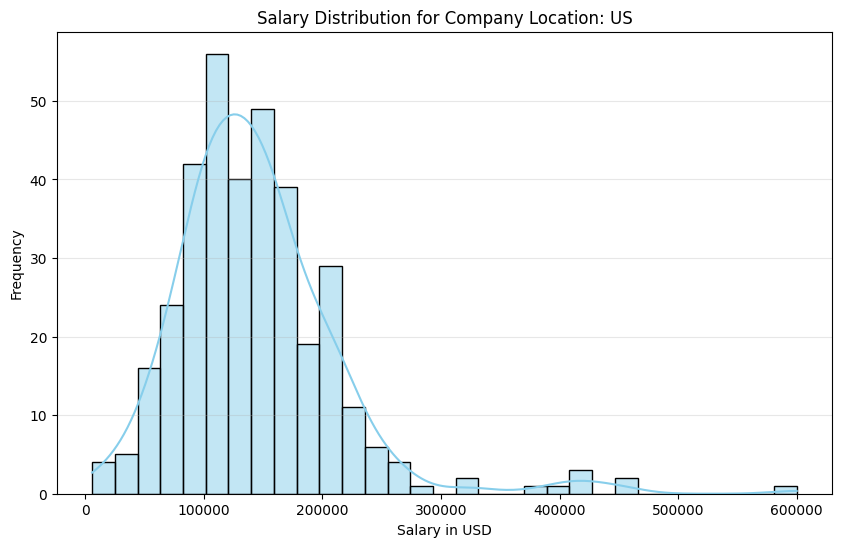

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the data for US company location
us_salaries = df_clean[df_clean['company_location'] == 'US']['salary_in_usd']

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(us_salaries, kde=True, color='skyblue')
plt.title('Salary Distribution for Company Location: US')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [23]:
COUNTRY_MAP: dict[str, dict[str, str]] = {
    "AE": {"region": "Middle East",     "tier": "High_Tier"},
    "AS": {"region": "Asia",            "tier": "Low_Tier"},
    "AT": {"region": "Europe",          "tier": "High_Tier"},
    "AU": {"region": "Oceania",         "tier": "High_Tier"},
    "BE": {"region": "Europe",          "tier": "High_Tier"},
    "BR": {"region": "South America",   "tier": "Low_Tier"},
    "CA": {"region": "North America",   "tier": "High_Tier"},
    "CH": {"region": "Europe",          "tier": "Mid_Tier"},
    "CL": {"region": "South America",   "tier": "Mid_Tier"},
    "CN": {"region": "Asia",            "tier": "High_Tier"},
    "CO": {"region": "South America",   "tier": "Low_Tier"},
    "CZ": {"region": "Europe",          "tier": "Mid_Tier"},
    "DE": {"region": "Europe",          "tier": "High_Tier"},
    "DK": {"region": "Europe",          "tier": "Mid_Tier"},
    "DZ": {"region": "Africa",          "tier": "High_Tier"},
    "EE": {"region": "Europe",          "tier": "Low_Tier"},
    "ES": {"region": "Europe",          "tier": "Mid_Tier"},
    "FR": {"region": "Europe",          "tier": "Mid_Tier"},
    "GB": {"region": "Europe",          "tier": "High_Tier"},
    "GR": {"region": "Europe",          "tier": "Mid_Tier"},
    "HN": {"region": "Central America", "tier": "Low_Tier"},
    "HR": {"region": "Europe",          "tier": "Mid_Tier"},
    "HU": {"region": "Europe",          "tier": "Low_Tier"},
    "IE": {"region": "Europe",          "tier": "High_Tier"},
    "IL": {"region": "Middle East",     "tier": "High_Tier"},
    "IN": {"region": "Asia",            "tier": "Low_Tier"},
    "IQ": {"region": "Middle East",     "tier": "High_Tier"},
    "IR": {"region": "Middle East",     "tier": "Low_Tier"},
    "IT": {"region": "Europe",          "tier": "Mid_Tier"},
    "JP": {"region": "Asia",            "tier": "High_Tier"},
    "KE": {"region": "Africa",          "tier": "Low_Tier"},
    "LU": {"region": "Europe",          "tier": "Mid_Tier"},
    "MD": {"region": "Europe",          "tier": "Low_Tier"},
    "MT": {"region": "Europe",          "tier": "Low_Tier"},
    "MX": {"region": "North America",   "tier": "Low_Tier"},
    "MY": {"region": "Asia",            "tier": "Mid_Tier"},
    "NG": {"region": "Africa",          "tier": "Low_Tier"},
    "NL": {"region": "Europe",          "tier": "Mid_Tier"},
    "NZ": {"region": "Oceania",         "tier": "High_Tier"},
    "PK": {"region": "Asia",            "tier": "Low_Tier"},
    "PL": {"region": "Europe",          "tier": "Mid_Tier"},
    "PT": {"region": "Europe",          "tier": "Mid_Tier"},
    "RO": {"region": "Europe",          "tier": "Mid_Tier"},
    "RU": {"region": "Europe",          "tier": "High_Tier"},
    "SG": {"region": "Asia",            "tier": "High_Tier"},
    "SI": {"region": "Europe",          "tier": "Mid_Tier"},
    "TR": {"region": "Middle East",     "tier": "Low_Tier"},
    "UA": {"region": "Europe",          "tier": "Low_Tier"},
    "US": {"region": "North America",   "tier": "High_Tier"},
    "VN": {"region": "Asia",            "tier": "Low_Tier"},
}

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract region mapping from the COUNTRY_MAP dictionary
# COUNTRY_MAP is defined in the previous cell
region_mapping = {country: details['region'] for country, details in COUNTRY_MAP.items()}

# 2. Add the Region column to the cleaned dataframe
df_clean['Region'] = df_clean['company_location'].map(region_mapping)

# Prepare readable labels for plotting
exp_labels = {'EN': 'Entry-Level', 'MI': 'Mid-Level', 'SE': 'Senior', 'EX': 'Executive'}
df_clean['Experience'] = df_clean['experience_level'].map(exp_labels)

print("Region column created using COUNTRY_MAP.")
display(df_clean[['company_location', 'Region', 'Experience']].head())

Region column created using COUNTRY_MAP.


,company_location,Region,Experience
0,DE,Europe,Mid-Level
1,JP,Asia,Senior
2,GB,Europe,Senior
3,HN,Central America,Mid-Level
4,US,North America,Senior


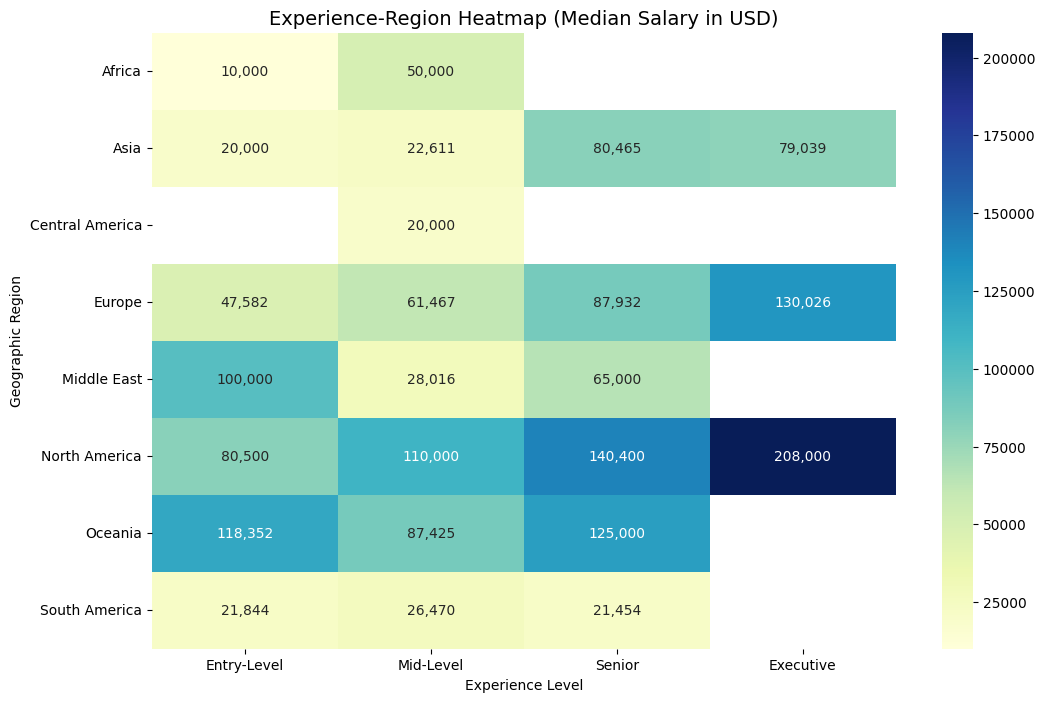

In [25]:
# 3. Updated Experience-Region Heatmap using COUNTRY_MAP regions
plt.figure(figsize=(12, 8))
heatmap_region_data = df_clean.pivot_table(index='Region', columns='Experience', values='salary_in_usd', aggfunc='median')

# Order columns by seniority
order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']
heatmap_region_data = heatmap_region_data[order]

sns.heatmap(heatmap_region_data, annot=True, fmt=",.0f", cmap='YlGnBu')
plt.title('Experience-Region Heatmap (Median Salary in USD)', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Geographic Region')
plt.show()

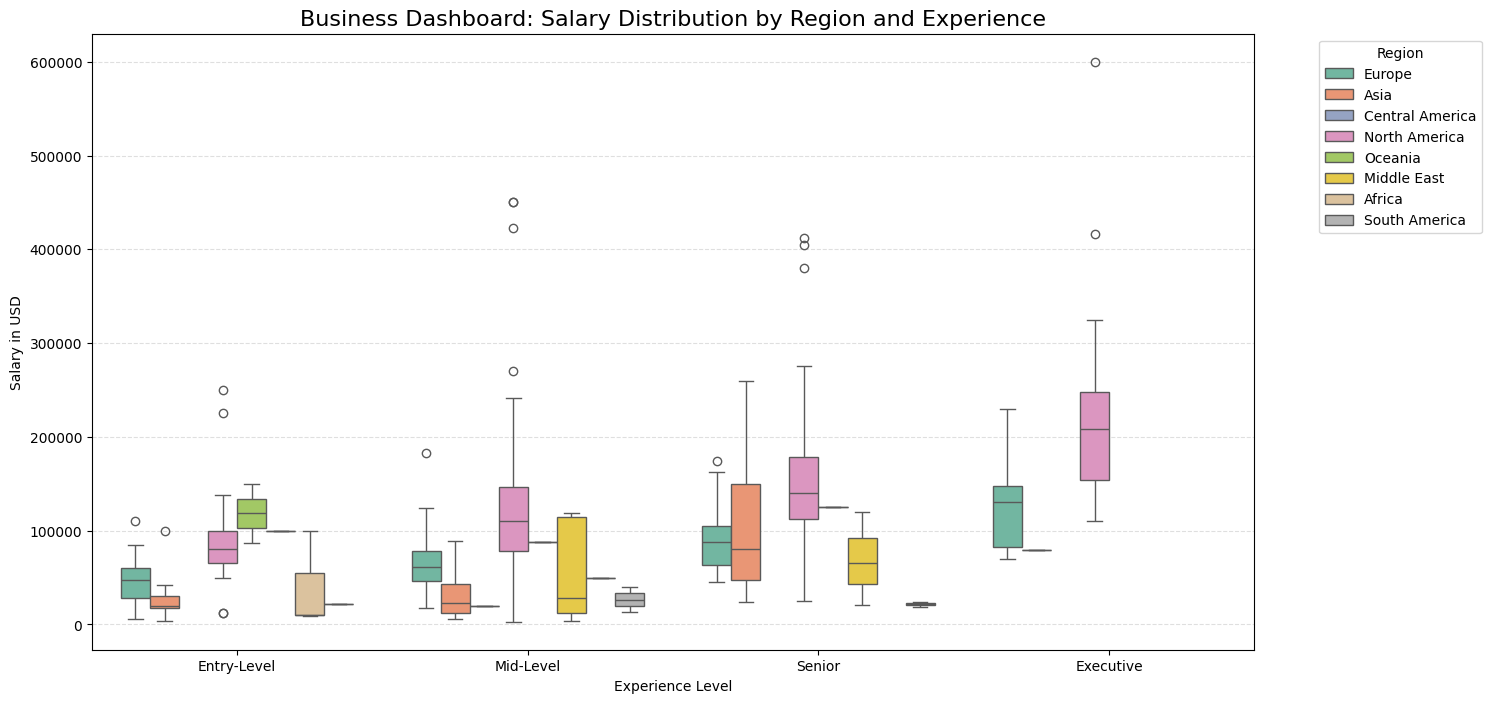

In [26]:
# 4. Business Dashboard: Grouped Boxplot using COUNTRY_MAP regions
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_clean, x='Experience', y='salary_in_usd', hue='Region',
            order=['Entry-Level', 'Mid-Level', 'Senior', 'Executive'], palette='Set2')

plt.title('Business Dashboard: Salary Distribution by Region and Experience', fontsize=16)
plt.ylabel('Salary in USD')
plt.xlabel('Experience Level')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

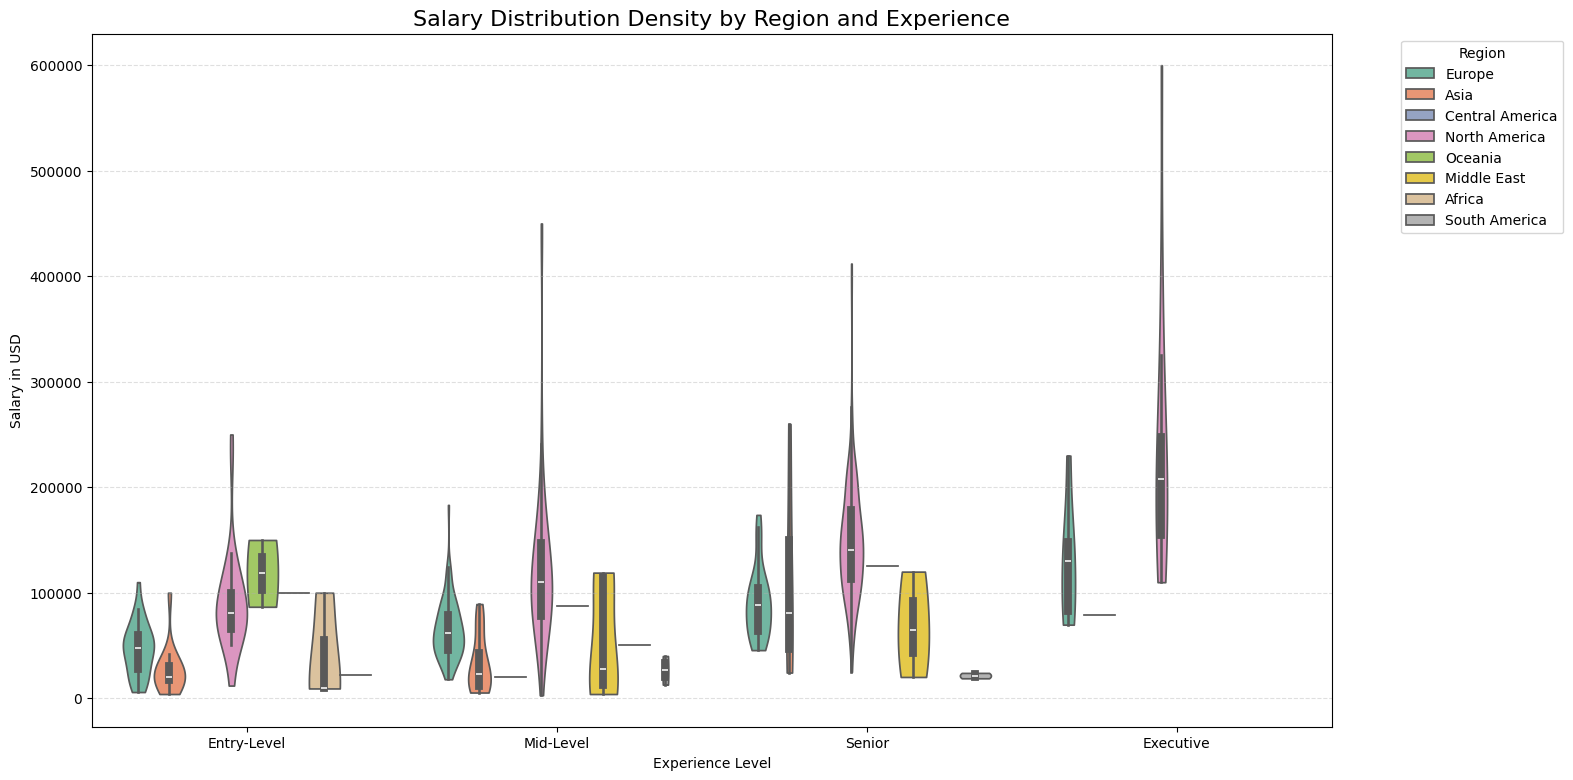

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Grouped Violin Plot using COUNTRY_MAP regions for detailed distribution
plt.figure(figsize=(16, 9))
sns.violinplot(data=df_clean, x='Experience', y='salary_in_usd', hue='Region',
               order=['Entry-Level', 'Mid-Level', 'Senior', 'Executive'],
               palette='Set2', split=False, cut=0)

plt.title('Salary Distribution Density by Region and Experience', fontsize=16)
plt.ylabel('Salary in USD')
plt.xlabel('Experience Level')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [28]:
df_clean.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category,Region,Experience
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L,Data Scientist,Europe,Mid-Level
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,Machine Learning Engineer,Asia,Senior
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,Data Engineer,Europe,Senior
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Data Analyst,Central America,Mid-Level
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L,Machine Learning Engineer,North America,Senior


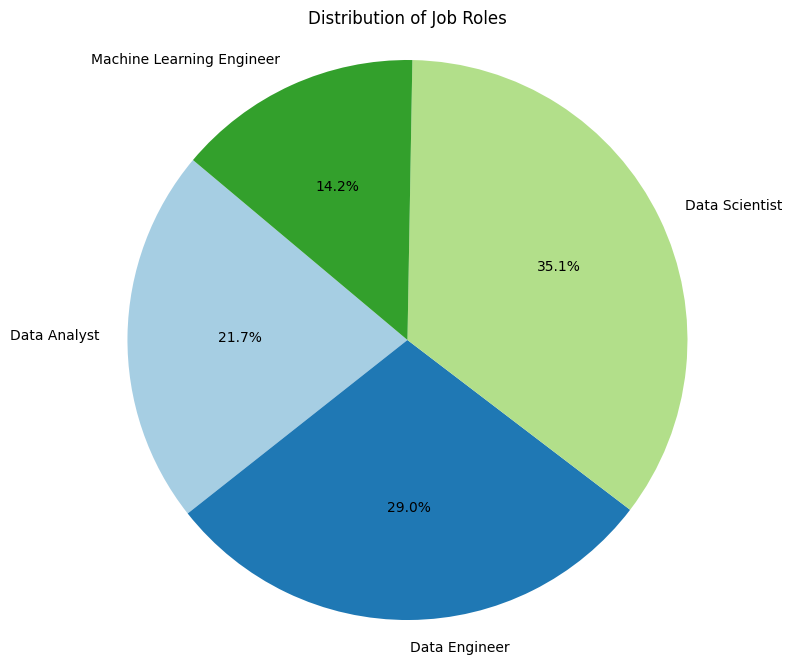

Salaries per Job Role (Median USD):


,Job Role,Median Salary
1,Data Engineer,111887.5
2,Data Scientist,110000.0
0,Data Analyst,92000.0
3,Machine Learning Engineer,81872.0


In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Group data by job_category to get counts and median salaries
role_stats = df_clean.groupby('job_category')['salary_in_usd'].agg(['count', 'median']).reset_index()
role_stats.rename(columns={'job_category': 'Job Role', 'count': 'Count', 'median': 'Median Salary'}, inplace=True)

# Create Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(role_stats['Count'], labels=role_stats['Job Role'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Distribution of Job Roles')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# Display the salaries per job role
print("Salaries per Job Role (Median USD):")
display(role_stats[['Job Role', 'Median Salary']].sort_values(by='Median Salary', ascending=False))

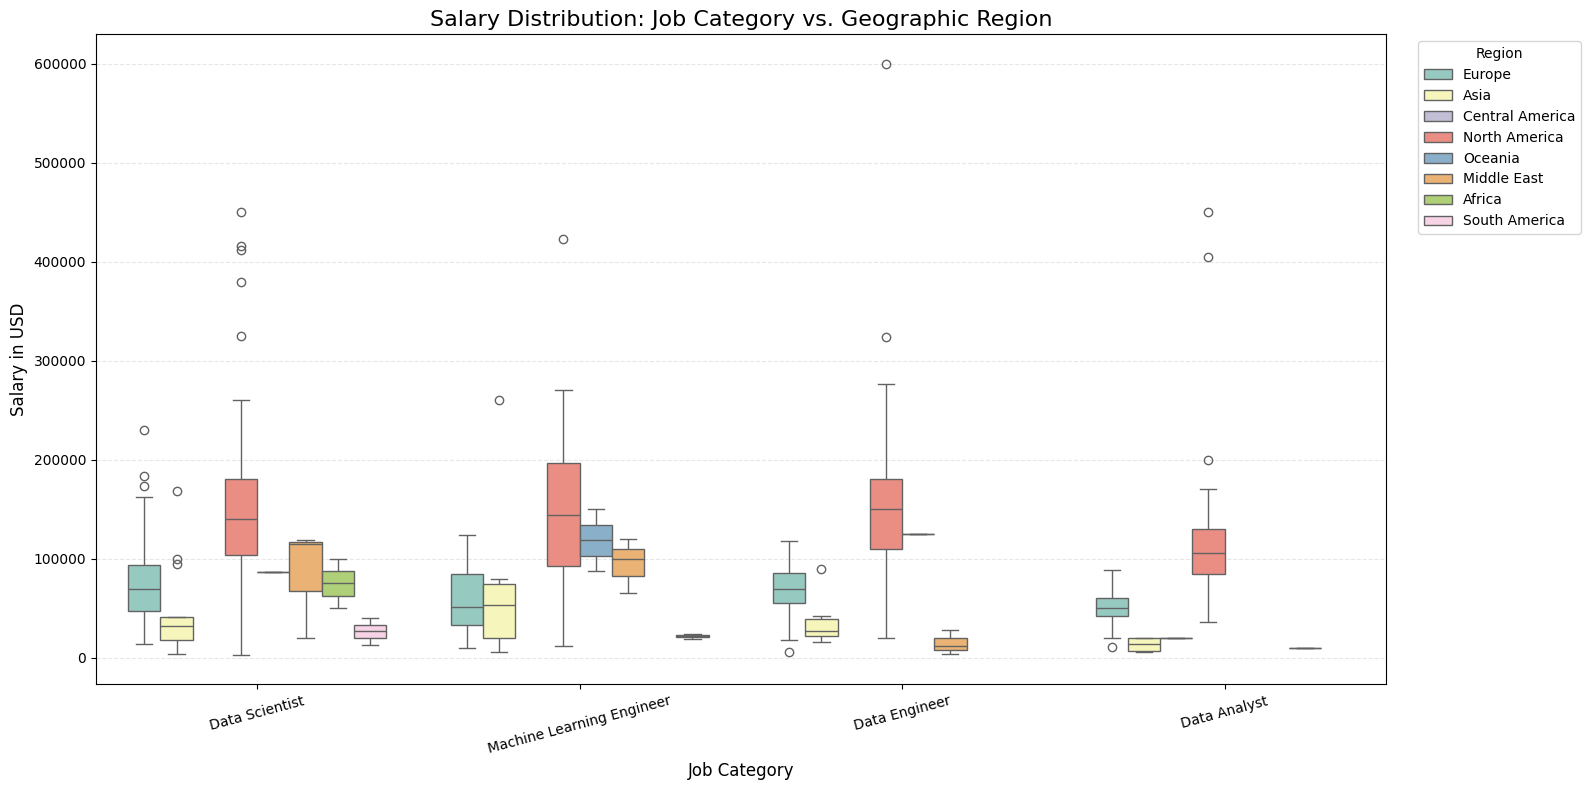

Median Salaries by Region and Job Category:


job_category,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer
Region,,,,
Africa,9636.0,NaN,75000.0,NaN
Asia,13221.0,26519.5,31615.0,53521.0
Central America,20000.0,NaN,NaN,NaN
Europe,50000.0,69741.0,69741.0,50622.0
Middle East,NaN,12103.0,115000.0,100000.0
North America,105830.0,150000.0,140000.0,144000.0
Oceania,NaN,125000.0,86703.0,118712.5
South America,NaN,NaN,26469.5,21844.0


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size for a detailed comparison
plt.figure(figsize=(16, 8))

# Create a grouped boxplot for Job Category and Region
sns.boxplot(data=df_clean, x='job_category', y='salary_in_usd', hue='Region', palette='Set3')

# Adding titles and labels
plt.title('Salary Distribution: Job Category vs. Geographic Region', fontsize=16)
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Salary in USD', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Adjust legend position to not overlap data
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Display median salaries for numerical context
region_job_stats = df_clean.groupby(['Region', 'job_category'])['salary_in_usd'].median().unstack().round(2)
print("Median Salaries by Region and Job Category:")
display(region_job_stats)

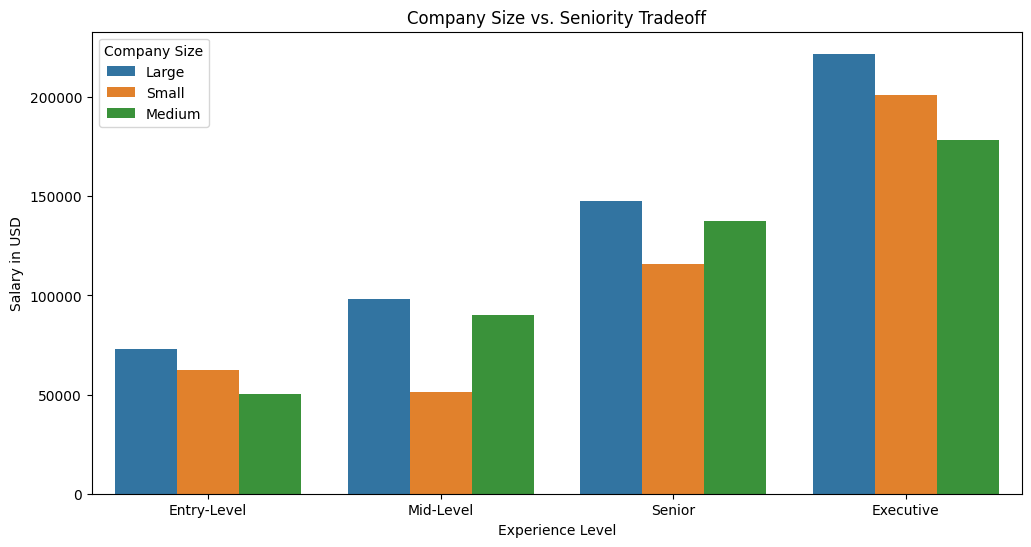

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a temporary dataframe for plotting with correct string mappings
df_plot = df_clean.copy()

# Correcting the mapping keys to match df_clean string values
exp_labels = {'EN': 'Entry-Level', 'MI': 'Mid-Level', 'SE': 'Senior', 'EX': 'Executive'}
size_labels = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}

df_plot['Experience'] = df_plot['experience_level'].map(exp_labels)
df_plot['Company Size'] = df_plot['company_size'].map(size_labels)

# 2. Company Size vs. Seniority Tradeoff
plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Experience', y='salary_in_usd', hue='Company Size',
            order=['Entry-Level', 'Mid-Level', 'Senior', 'Executive'], errorbar=None)

plt.title('Company Size vs. Seniority Tradeoff')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')
plt.legend(title='Company Size')
plt.show()

In [32]:
# Filter for Executive (EX) experience and Small (S) company size
ex_small_company = df_clean[(df_clean['experience_level'] == 'EX') & (df_clean['company_size'] == 'S')]

count_ex_small = len(ex_small_company)
print(f"Number of Executive (EX) instances in Small (S) companies: {count_ex_small}")

if count_ex_small > 0:
    display(ex_small_company)

Number of Executive (EX) instances in Small (S) companies: 3


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category,Region,Experience
187,2021,EX,FT,Data Science Consultant,59000,EUR,69741,FR,100,ES,S,Data Scientist,Europe,Executive
225,2021,EX,CT,Principal Data Scientist,416000,USD,416000,US,100,US,S,Data Scientist,North America,Executive
375,2022,EX,FT,Lead Data Engineer,150000,CAD,118187,CA,100,CA,S,Data Engineer,North America,Executive


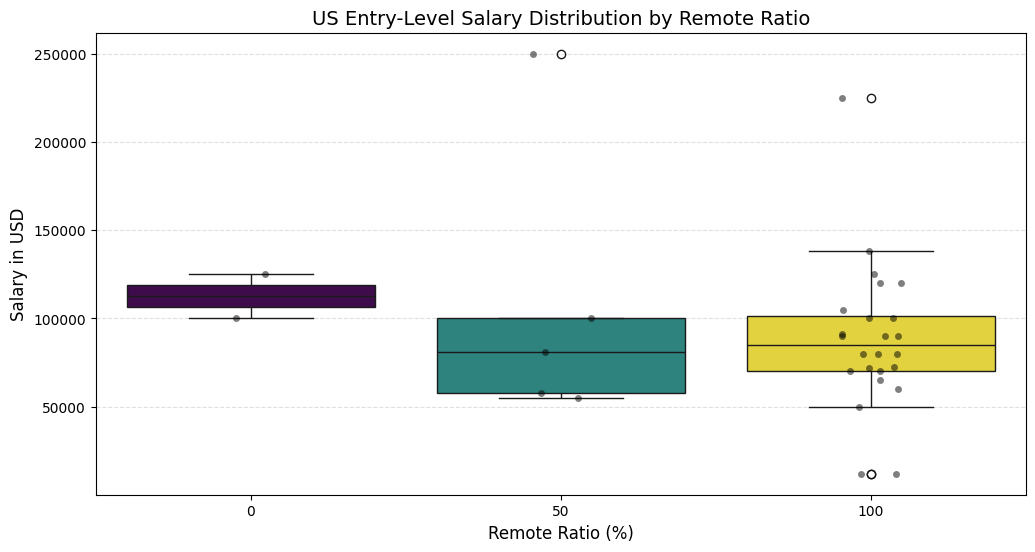

Total US Entry-Level records: 31


,count,mean,median,min,max
remote_ratio,,,,,
0,2,112500.00,112500.0,100000,125000
50,5,108800.00,81000.0,55000,250000
100,24,88229.17,85000.0,12000,225000


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter data for Entry-level (EN) roles in the United States (US)
us_entry_level = df_clean[(df_clean['experience_level'] == 'EN') & (df_clean['company_location'] == 'US')]

# 2. Plot the distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=us_entry_level, x='remote_ratio', y='salary_in_usd', palette='viridis', hue='remote_ratio', legend=False)
sns.stripplot(data=us_entry_level, x='remote_ratio', y='salary_in_usd', color='black', alpha=0.5)

plt.title('US Entry-Level Salary Distribution by Remote Ratio', fontsize=14)
plt.xlabel('Remote Ratio (%)', fontsize=12)
plt.ylabel('Salary in USD', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# 3. Display summary statistics
print(f"Total US Entry-Level records: {len(us_entry_level)}")
display(us_entry_level.groupby('remote_ratio')['salary_in_usd'].agg(['count', 'mean', 'median', 'min', 'max']).round(2))

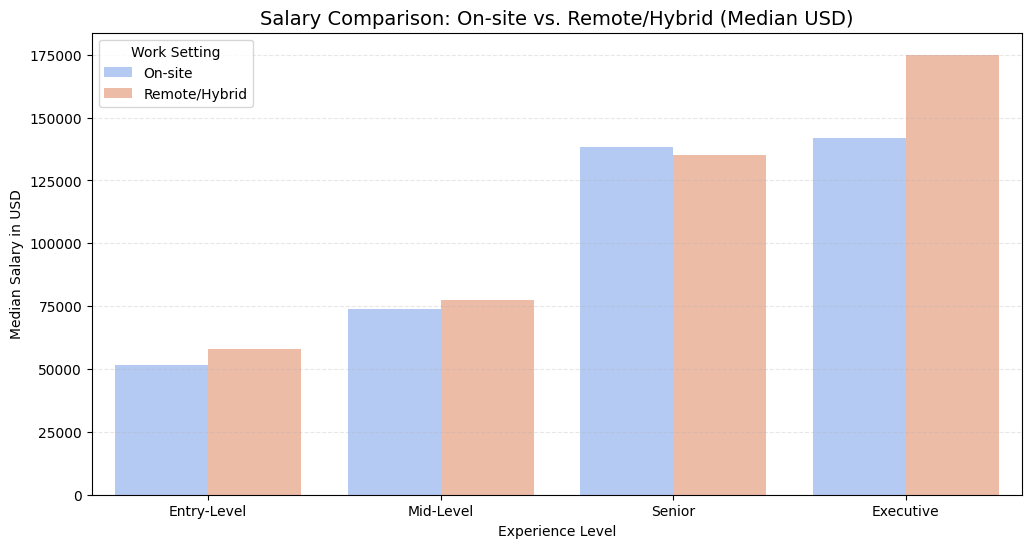

Median Salary Comparison Table:


work_setting,On-site,Remote/Hybrid
Experience,,
Entry-Level,51660.5,58017.5
Mid-Level,74000.0,77364.0
Senior,138200.0,135000.0
Executive,141846.0,175000.0


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a binary feature for On-site vs. Remote/Hybrid
df_work_type = df_clean.copy()
df_work_type['work_setting'] = df_work_type['remote_ratio'].apply(lambda x: 'On-site' if x == 0 else 'Remote/Hybrid')

# 2. Map experience labels for readability
exp_order = ['Entry-Level', 'Mid-Level', 'Senior', 'Executive']
df_work_type['Experience'] = df_work_type['experience_level'].map({'EN': 'Entry-Level', 'MI': 'Mid-Level', 'SE': 'Senior', 'EX': 'Executive'})

# 3. Plot the comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_work_type, x='Experience', y='salary_in_usd', hue='work_setting',
            order=exp_order, estimator='median', errorbar=None, palette='coolwarm')

plt.title('Salary Comparison: On-site vs. Remote/Hybrid (Median USD)', fontsize=14)
plt.ylabel('Median Salary in USD')
plt.xlabel('Experience Level')
plt.legend(title='Work Setting')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# 4. Display the raw numbers
comparison_table = df_work_type.groupby(['Experience', 'work_setting'])['salary_in_usd'].median().unstack().reindex(exp_order)
print("Median Salary Comparison Table:")
display(comparison_table)

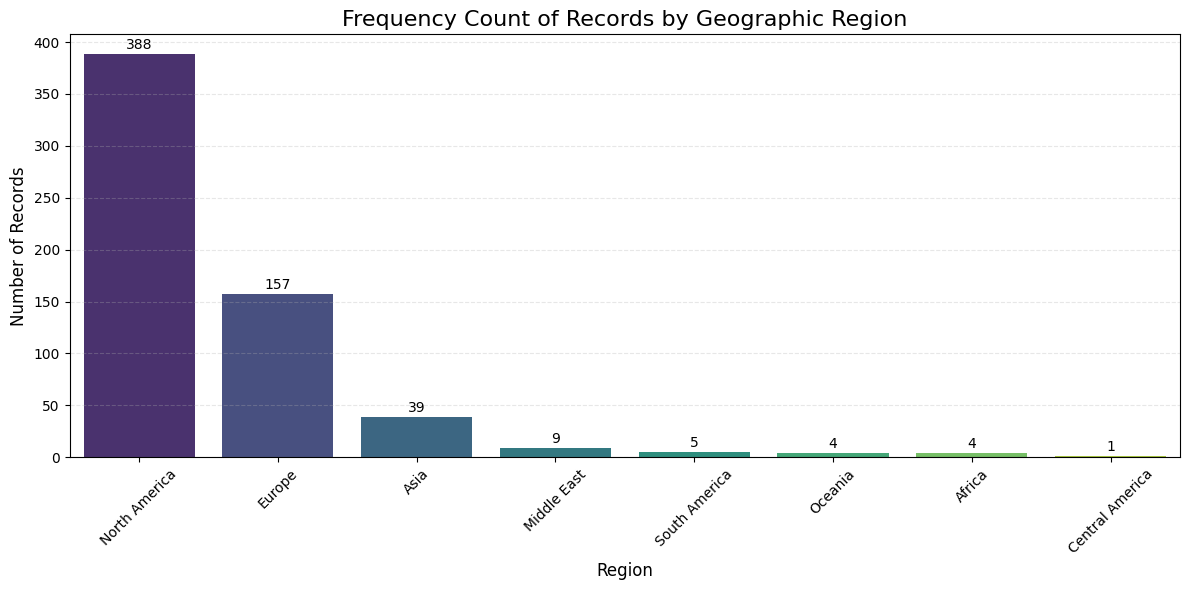

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate counts and sort for a better visual flow
region_counts = df_clean['Region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(data=region_counts, x='Region', y='Count', palette='viridis', hue='Region', legend=False)

plt.title('Frequency Count of Records by Geographic Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add count labels on top of the bars
for i, count in enumerate(region_counts['Count']):
    plt.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

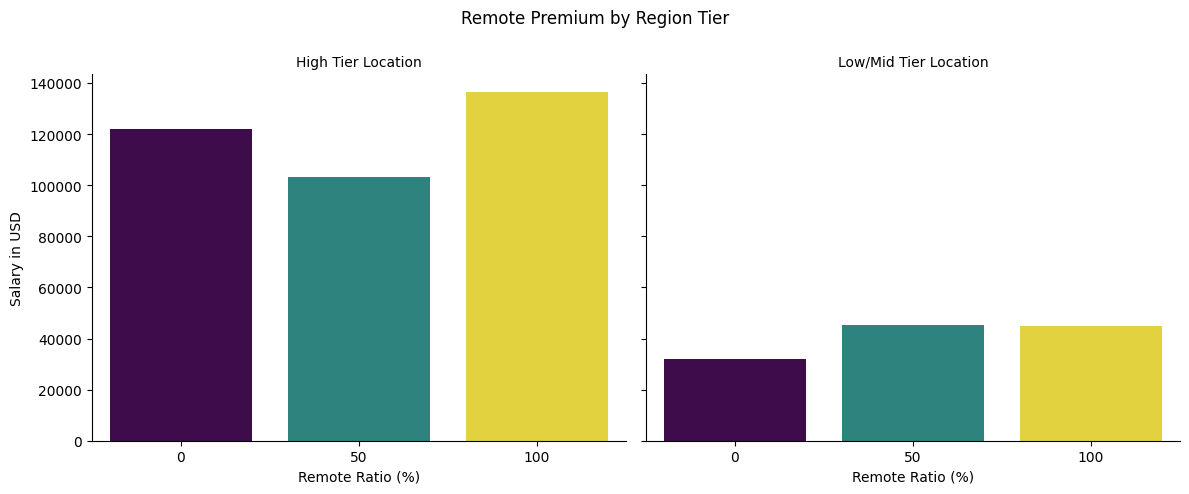

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create readable labels for the facets based on the categorical 'location_tier' column
df_remote_plot = df_model.copy()
# Map the categorical values to descriptive labels
df_remote_plot['Tier_Label'] = df_remote_plot['location_tier'].map({
    'High_Tier': 'High Tier Location',
    'Mid_Tier': 'Low/Mid Tier Location',
    'Low_Tier': 'Low/Mid Tier Location'
})

# 3. Remote Premium by Region (Faceted)
g = sns.FacetGrid(df_remote_plot, col='Tier_Label', height=5, aspect=1.2)
# Updated to assign hue=x to avoid FutureWarning
g.map_dataframe(sns.barplot, x='remote_ratio', y='salary_in_usd', hue='remote_ratio', palette='viridis', errorbar=None, legend=False)
g.set_axis_labels("Remote Ratio (%)", "Salary in USD")
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Remote Premium by Region Tier')
plt.show()

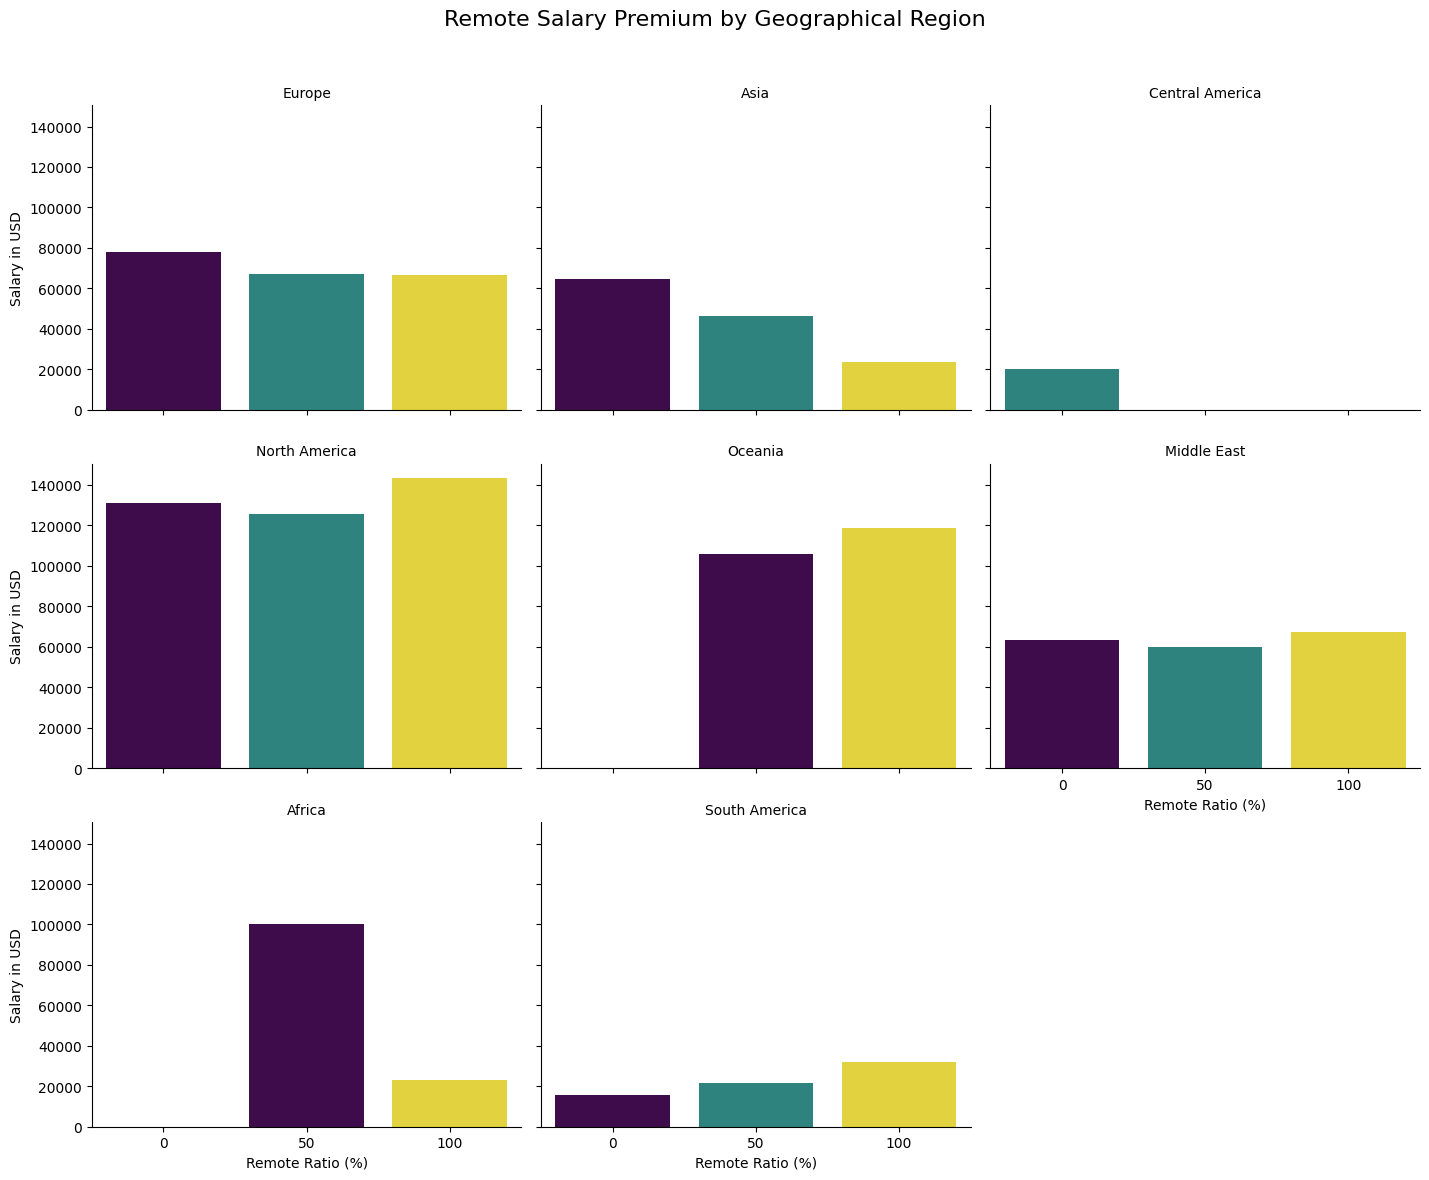

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a region mapping from COUNTRY_MAP
region_map = {country: details['region'] for country, details in COUNTRY_MAP.items()}

# 2. Prepare the plotting dataframe
df_remote_region = df_clean.copy()
df_remote_region['Region'] = df_remote_region['company_location'].map(region_map)

# 3. Create Faceted Bar Plot by Region
g = sns.FacetGrid(df_remote_region, col='Region', col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.barplot, x='remote_ratio', y='salary_in_usd', hue='remote_ratio', palette='viridis', errorbar=None, legend=False)

g.set_axis_labels("Remote Ratio (%)", "Salary in USD")
g.set_titles(col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Remote Salary Premium by Geographical Region', fontsize=16)
plt.show()

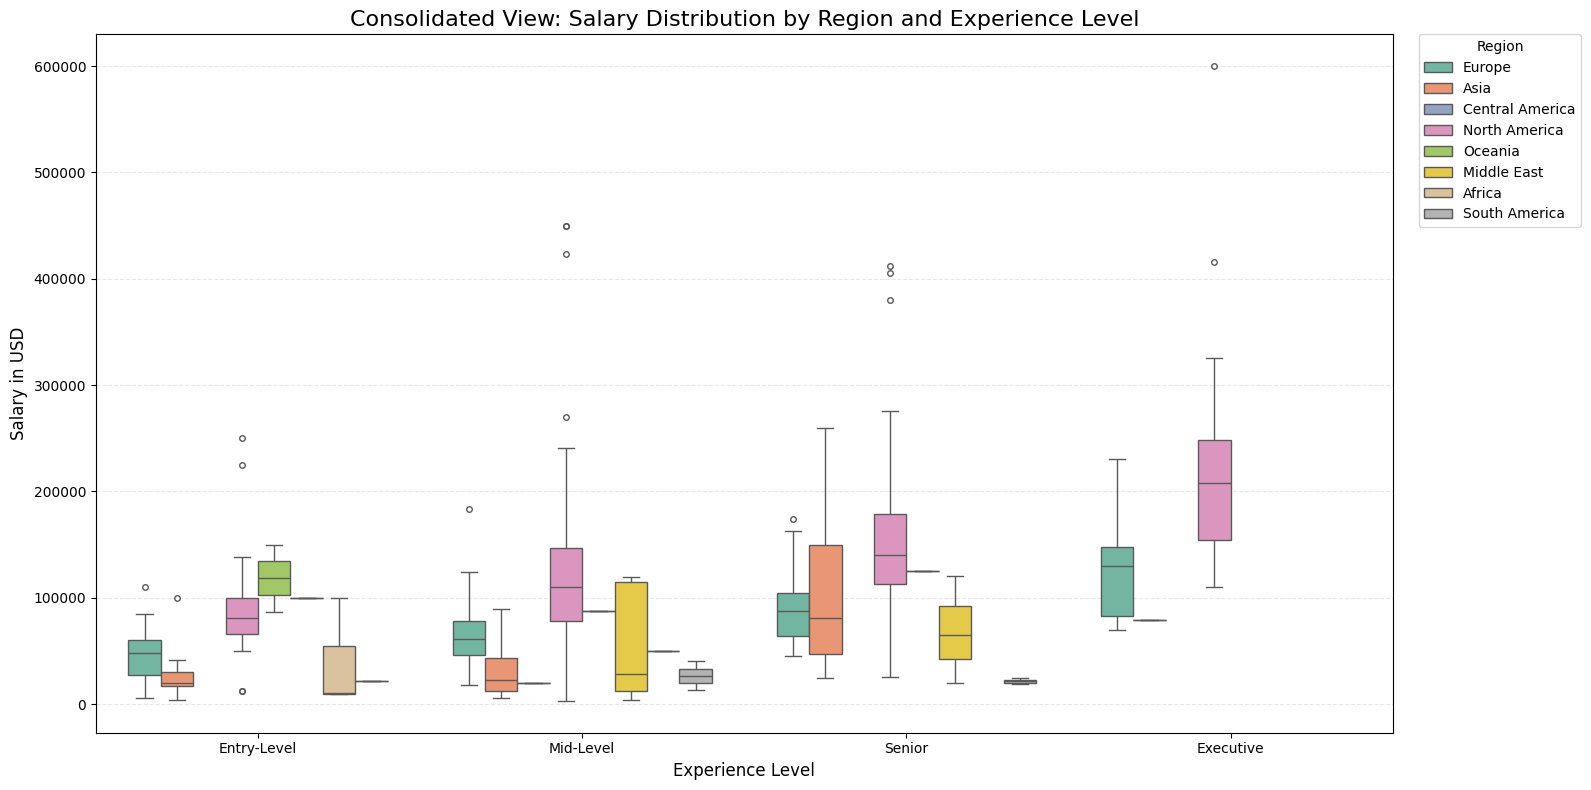

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a consolidated view using a grouped boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df_clean, x='Experience', y='salary_in_usd', hue='Region',
            order=['Entry-Level', 'Mid-Level', 'Senior', 'Executive'],
            palette='Set2', fliersize=4)

plt.title('Consolidated View: Salary Distribution by Region and Experience Level', fontsize=16)
plt.ylabel('Salary in USD', fontsize=12)
plt.xlabel('Experience Level', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [39]:
# Query rows where salary < 20,000 and company_location is 'US'
low_salary_us = df_clean[(df_clean['salary_in_usd'] < 20000) & (df_clean['company_location'] == 'US')]

print(f"Found {len(low_salary_us)} records matching the criteria.")
display(low_salary_us)

Found 3 records matching the criteria.


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_category,Region,Experience
96,2021,EN,PT,AI Scientist,12000,USD,12000,BR,100,US,S,Machine Learning Engineer,North America,Entry-Level
113,2021,EN,PT,AI Scientist,12000,USD,12000,PK,100,US,M,Machine Learning Engineer,North America,Entry-Level
179,2021,MI,FT,Data Scientist,420000,INR,5679,IN,100,US,S,Data Scientist,North America,Mid-Level


In [40]:
# Step 2: Feature Interaction (Handling Multicollinearity)
df_model['is_same_country'] = (df_model['employee_residence'] == df_model['company_location']).astype(int)
df_model = df_model.drop(columns=['company_location', 'employee_residence'])
print(f"New column 'is_same_country' created. Original location columns dropped.")

New column 'is_same_country' created. Original location columns dropped.


In [41]:
# Step 3: Remove Data Leakage
df_model = df_model.drop(columns=['salary', 'salary_currency'])
print("Dropped 'salary' and 'salary_currency' to prevent leakage.")

Dropped 'salary' and 'salary_currency' to prevent leakage.


In [42]:
# Step 4: Ordinal Encoding
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
size_map = {'S': 0, 'M': 1, 'L': 2}

df_model['experience_level'] = df_model['experience_level'].map(exp_map)
df_model['company_size'] = df_model['company_size'].map(size_map)
display(df_model[['experience_level', 'company_size']].head())

,experience_level,company_size
0,1,2
1,2,0
2,2,1
3,1,0
4,2,2


In [43]:
# Step 5: One-Hot Encoding
nominal_cols = ['job_category', 'employment_type', 'location_tier']
df_model = pd.get_dummies(df_model, columns=nominal_cols)

# Convert booleans to integers and drop original job_title
bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

if 'job_title' in df_model.columns:
    df_model = df_model.drop(columns=['job_title'])

print(f"Final Preprocessed Shape: {df_model.shape}")
display(df_model.head())

Final Preprocessed Shape: (607, 17)


,work_year,experience_level,salary_in_usd,remote_ratio,company_size,is_same_country,job_category_Data Analyst,job_category_Data Engineer,job_category_Data Scientist,job_category_Machine Learning Engineer,employment_type_CT,employment_type_FL,employment_type_FT,employment_type_PT,location_tier_High_Tier,location_tier_Low_Tier,location_tier_Mid_Tier
0,2020,1,79833,0,2,1,0,0,1,0,0,0,1,0,1,0,0
1,2020,2,260000,0,0,1,0,0,0,1,0,0,1,0,1,0,0
2,2020,2,109024,50,1,1,0,1,0,0,0,0,1,0,1,0,0
3,2020,1,20000,0,0,1,1,0,0,0,0,0,1,0,0,1,0
4,2020,2,150000,50,2,1,0,0,0,1,0,0,1,0,1,0,0


## Model Training and Evaluation

In this section, we split the preprocessed `df_model` into training, validation, and test sets, then train a Decision Tree Regressor to predict salaries.

In [44]:
# ==========================================
# 1. LOAD PREPROCESSED DATA
# ==========================================
import pandas as pd
import numpy as np

# Using df_model which was prepared in the previous preprocessing steps
X = df_model.drop('salary_in_usd', axis=1)
y = df_model['salary_in_usd']

print("Features and Target assigned.")
display(X.head())

Features and Target assigned.


,work_year,experience_level,remote_ratio,company_size,is_same_country,job_category_Data Analyst,job_category_Data Engineer,job_category_Data Scientist,job_category_Machine Learning Engineer,employment_type_CT,employment_type_FL,employment_type_FT,employment_type_PT,location_tier_High_Tier,location_tier_Low_Tier,location_tier_Mid_Tier
0,2020,1,0,2,1,0,0,1,0,0,0,1,0,1,0,0
1,2020,2,0,0,1,0,0,0,1,0,0,1,0,1,0,0
2,2020,2,50,1,1,0,1,0,0,0,0,1,0,1,0,0
3,2020,1,0,0,1,1,0,0,0,0,0,1,0,0,1,0
4,2020,2,50,2,1,0,0,0,1,0,0,1,0,1,0,0


In [45]:
# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
from sklearn.model_selection import train_test_split

# We hold out 20% of the data as a final blind test.
# random_state=42 ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training data size: {X_train.shape[0]} rows")
print(f"Testing data size: {X_test.shape[0]} rows")

Training data size: 485 rows
Testing data size: 122 rows


In [46]:
# Identify employment type columns (they start with 'employment_type_')
emp_cols = [col for col in X_train.columns if col.startswith('employment_type_')]

print("=== Employment Type Frequencies (Train Set) ===")
print(X_train[emp_cols].sum().sort_values(ascending=False))

print("\n=== Employment Type Frequencies (Test Set) ===")
print(X_test[emp_cols].sum().sort_values(ascending=False))

=== Employment Type Frequencies (Train Set) ===
employment_type_FT    471
employment_type_PT      8
employment_type_CT      4
employment_type_FL      2
dtype: int64

=== Employment Type Frequencies (Test Set) ===
employment_type_FT    117
employment_type_FL      2
employment_type_PT      2
employment_type_CT      1
dtype: int64


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Initialize the Linear Regressor
lin_reg = LinearRegression()

# 2. Fit the model using the existing training data
lin_reg.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred_lin = lin_reg.predict(X_test)

# 4. Calculate Evaluation Metrics
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("=== Linear Regression Performance ===")
print(f"RMSE: ${rmse_lin:,.2f}")
print(f"MAE:  ${mae_lin:,.2f}")
print(f"R2 Score: {r2_lin:.4f}")

# Optional: Display coefficients to see feature importance
coeff_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lin_reg.coef_})
print("\nTop 5 Coefficients:")
display(coeff_df.sort_values(by='Coefficient', ascending=False).head())


=== Linear Regression Performance ===
RMSE: $44,817.88
MAE:  $33,061.04
R2 Score: 0.4759

Top 5 Coefficients:


,Feature,Coefficient
9,employment_type_CT,52574.039934
13,location_tier_High_Tier,51448.426687
4,is_same_country,35632.545958
1,experience_level,34784.614906
3,company_size,15959.655169


In [48]:
# ==========================================
# 3. HYPERPARAMETER GRID SETUP (EXPANDED)
# ==========================================
# Expanding the search space to find a better performing model
param_grid = {
    'max_depth':  [7,9,13,17],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10, 12],
    'max_features': [None, 'sqrt', 'log2']
}
print(f"Expanded hyperparameter grid defined with {3*7*6*7*3} potential combinations.")

Expanded hyperparameter grid defined with 2646 potential combinations.


In [49]:
# ==========================================
# 4. CROSS-VALIDATION & TRAINING
# ==========================================
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Initialize the base model
dt_regressor = DecisionTreeRegressor(random_state=42)

# Set up the Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=dt_regressor,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search for best hyperparameters...")
grid_search.fit(X_train, y_train)

# Extract the winning model
best_model = grid_search.best_estimator_

print("\n=== Training Complete ===")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")

Starting Grid Search for best hyperparameters...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits

=== Training Complete ===
Best Hyperparameters Found: {'max_depth': 9, 'max_features': None, 'min_samples_leaf': 12, 'min_samples_split': 2}


In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Define the Hyperparameter Grid for Random Forest
rf_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# 2. Initialize and Train the Model using GridSearchCV
rf_base = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print("Starting Grid Search for Random Forest...")
rf_grid_search.fit(X_train, y_train)

# 3. Extract and Evaluate the Best Model
best_rf_model = rf_grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)

# 4. Calculate Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== Random Forest Performance ===")
print(f"Best Params: {rf_grid_search.best_params_}")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"MAE:  ${mae_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Starting Grid Search for Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

=== Random Forest Performance ===
Best Params: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
RMSE: $46,115.83
MAE:  $31,399.87
R2 Score: 0.4451


In [51]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 1. Initialize XGBoost Regressor
# Using some standard parameters for a baseline
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# 2. Train the model
xgb_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("=== XGBoost Regressor Performance ===")
print(f"RMSE: ${rmse_xgb:,.2f}")
print(f"MAE:  ${mae_xgb:,.2f}")
print(f"R2 Score: {r2_xgb:.4f}")

=== XGBoost Regressor Performance ===
RMSE: $46,901.04
MAE:  $31,992.98
R2 Score: 0.4260


=== Feature Importance Matrix ===


,Feature,Importance
13,location_tier_High_Tier,0.380569
1,experience_level,0.359419
3,company_size,0.082819
5,job_category_Data Analyst,0.048744
0,work_year,0.029371
2,remote_ratio,0.027491
4,is_same_country,0.020255
8,job_category_Machine Learning Engineer,0.015761
6,job_category_Data Engineer,0.010588
7,job_category_Data Scientist,0.006385


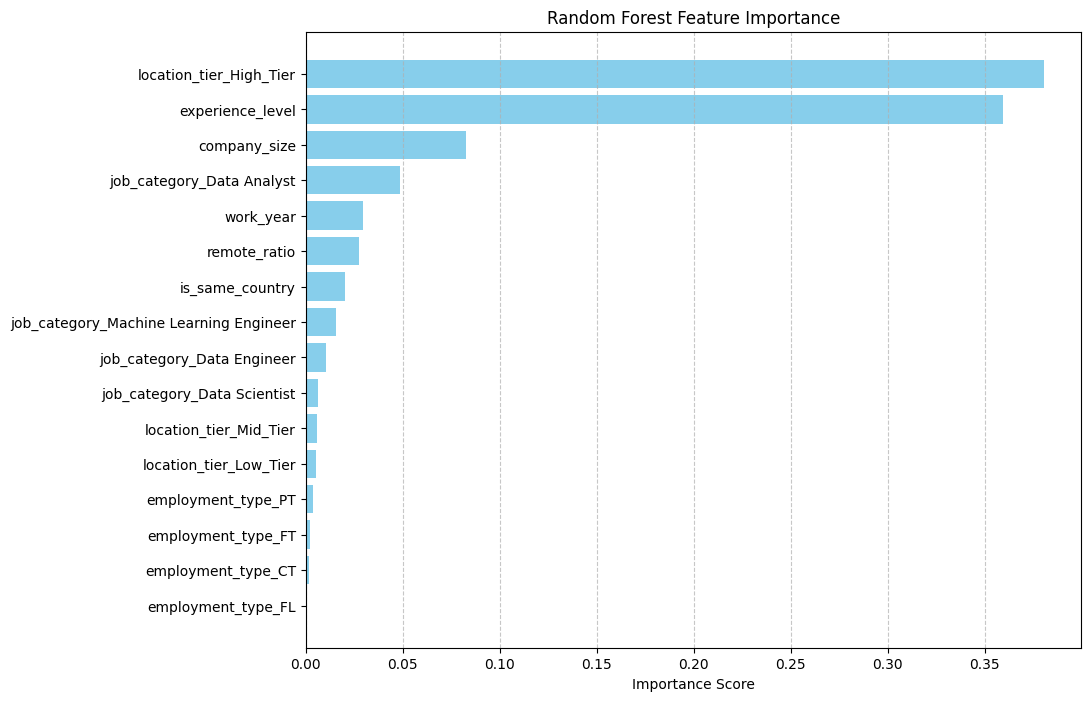

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances from the best Random Forest model
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Display the Importance Matrix (Top 10)
print("=== Feature Importance Matrix ===")
display(feature_importance_df)

# 4. Plot the Feature Importances
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [53]:
# ==========================================
# 5. FINAL EVALUATION
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Test the winning model on the 20% holdout data it has NEVER seen.
y_pred = best_model.predict(X_test)

# Calculate Metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Final Test Model Performance:")
print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R2 Score: {r2:.4f}")

Final Test Model Performance:
MSE:  2,266,538,087.58
RMSE: $47,608.17
MAE:  $32,487.21
R2 Score: 0.4086


In [54]:
import json

# Extracting only Random Forest metrics
rf_metrics = {
    "model": "Random Forest Regressor",
    "rmse": rmse_rf,
    "mae": mae_rf,
    "r2_score": r2_rf
}

# Save to a JSON file
with open('rf_metrics.json', 'w') as f:
    json.dump(rf_metrics, f, indent=4)

print("Random Forest metrics successfully saved to rf_metrics.json:")
print(json.dumps(rf_metrics, indent=4))

Random Forest metrics successfully saved to rf_metrics.json:
{
    "model": "Random Forest Regressor",
    "rmse": 46115.83055817234,
    "mae": 31399.86575686748,
    "r2_score": 0.44510595110290396
}


In [55]:
# ==========================================
# 6. SAVE THE MODEL
# ==========================================
import joblib
import os

# Create a 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the trained model to disk using joblib
model_path = 'models/randomforest_v1.joblib'
joblib.dump(best_model, model_path)

print(f"Model successfully saved to {model_path}")

Model successfully saved to models/randomforest_v1.joblib


In [56]:
import joblib
import os

# Consolidate all mappings used in the feature engineering process
feature_mappings = {
    'job_category_map': job_category_map,
    'country_tier_map': country_tier_map,
    'experience_level_map': exp_map,
    'company_size_map': size_map,
    'nominal_columns': nominal_cols
}

# Ensure the models directory exists
os.makedirs('models', exist_ok=True)

# Save the mappings dictionary
mapping_path = 'models/feature_mappings.joblib'
joblib.dump(feature_mappings, mapping_path)

print(f"All feature engineering mappings successfully saved to {mapping_path}")
# Display keys to confirm what was saved
print("Mappings included:", list(feature_mappings.keys()))

All feature engineering mappings successfully saved to models/feature_mappings.joblib
Mappings included: ['job_category_map', 'country_tier_map', 'experience_level_map', 'company_size_map', 'nominal_columns']


In [57]:
import os

# Create a directory for datasets
os.makedirs('processed_data', exist_ok=True)

# 1. Save the full preprocessed model data
df_model.to_csv('processed_data/final_dataset_preprocessed.csv', index=False)

# 2. Save the splits
# We need to reconstruct the splits with their targets for CSV export
train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

# Save to CSV
train_set.to_csv('processed_data/train_split.csv', index=False)
test_set.to_csv('processed_data/test_split.csv', index=False)

# Since we are using GridSearchCV which handles internal CV,
# if you have a specific X_val/y_val from earlier steps, we save that too
if 'X_val' in globals() and 'y_val' in globals():
    val_set = pd.concat([X_val, y_val], axis=1)
    val_set.to_csv('processed_data/val_split.csv', index=False)
    print("Saved: final_dataset, train, test, and val CSVs.")
else:
    print("Saved: final_dataset, train, and test CSVs.")

Saved: final_dataset, train, and test CSVs.


In [58]:
import itertools
import pandas as pd

def generate_all_combinations():
    # 1. Define all possible options
    jobs = ['Data Analyst', 'Data Engineer', 'Data Scientist', 'Machine Learning Engineer']
    exp_levels = ['EN', 'MI', 'SE', 'EX']
    sizes = ['S', 'M', 'L']
    tiers = ['High_Tier', 'Mid_Tier', 'Low_Tier']
    emp_types = ['FT', 'PT', 'CT', 'FL']
    same_country = [1, 0]

    # 2. Create the Cartesian product (all 1,152 combinations)
    all_combos = list(itertools.product(jobs, exp_levels, sizes, tiers, emp_types, same_country))

    # Format into a list of dictionaries
    payloads = []
    for combo in all_combos:
        payloads.append({
            "job_category": combo[0],
            "experience_level": combo[1],
            "company_size": combo[2],
            "location_tier": combo[3],
            "employment_type": combo[4],
            "is_same_country": combo[5]
        })
    return payloads

def calculate_global_context(df_clean):
    # Calculate baseline stats from your training data ONCE to feed the LLM
    medians_by_job = df_clean.groupby('job_category')['salary_in_usd'].median().to_dict()
    medians_by_exp = df_clean.groupby('experience_level')['salary_in_usd'].median().to_dict()

    return {
        "job_medians": medians_by_job,
        "exp_medians": medians_by_exp
    }


In [59]:
payloads = generate_all_combinations()